In [42]:
class Data:
    def __init__(self, metal,mu_bulk, mu_aqueous_ion, mu_complex, mu_ligand, ligand_concentration, ion_activity):
        self.metal = metal
        self.mu_bulk = mu_bulk
        self.mu_aqueous_ion = mu_aqueous_ion
        self.mu_complex = mu_complex
        self.mu_ligand = mu_ligand
        self.ligand_concentration = ligand_concentration
        self.total_solid_species = len(mu_bulk)
        self.total_aq_species = len(mu_aqueous_ion) + len(mu_complex)
        self.ion_activity = ion_activity
        

class Thermodynamics:
    def __init__(self):
        self.kB = 8.6173e-5  # eV/K
        self.T = 298.15# 348.15 #298.15 # K
        self.mu_H2O = -2.458  # Reference for water
        self.correct_ion=True
    
    def apply_ion_correction(self, species):
#         return species.mu + self.kB*self.T*np.log(1e-6)
        return species.mu + self.kB*self.T*np.log(species.activity)
    


In [36]:
import numpy as np
import copy

import re
from ase.symbols import string2symbols
from scipy.optimize import linprog
from scipy.spatial import HalfspaceIntersection

class Species:
    def __init__(self, formula, metal,thermo, data, phase, activity):
        self.formula = formula
        self.metal = metal
        self.thermo = thermo
        self.data = data
        self.phase = phase #'bulk', 'aqueous_ion','ligand','complex'
        self.activity = activity
        self.ligand = None
        self.mu = self.get_mu()
        if self.phase == 'complex':
            self.composition = self.parse_complex_composition()
            
        else:
            self.composition = self.parse_formula_composition()
        if self.phase =='ligand':
            self.activity = data.ligand_concentration[formula]
        
    
    def parse_formula_composition(self):
        formula = self.formula.split('(aq)')[0]
        composition = {'charge': 0,
                       'H': 0,
                       'O': 0,
                       self.metal:0}
        ############## count n of electrons and protons ##############
        match = re.search(r'\[(\d*)([+-])\]', formula)
        if match:
            charge = match.group(1)
            sign = match.group(2)
            composition['charge'] = int(sign + charge)

        ############## count n of O and H ##############
        element_only_form = formula.split('[')[0]
        symbol_list = string2symbols(element_only_form)
        for symbol in symbol_list:
            if symbol in composition:
                composition[symbol] += 1
        return composition
    
    def parse_complex_composition(self):
        composition = {'H': 0,
                       'O': 0,
                       'charge': 0,
                       self.metal:0}
        ############## count n of electrons and protons ##############
        match = re.search(r'\[(\d*)([+-])\]', self.formula)
        if match:
            charge = match.group(1)
            sign = match.group(2)
            composition['charge'] = int(sign + charge)
        ############## count n of ligands ##############
        pattern = r'([A-Za-z]+)?\(?([A-Za-z0-9]+)\)?(\d*)'
        match = re.search(pattern, self.formula)
        if match:
            metal = match.group(1)      # Metal symbol (e.g., Ni)
            ligand = match.group(2)     # Ligand (e.g., NH3)
            ligand_count = match.group(3)  # Ligand count (e.g., 4, could be empty)

            # If the ligand count is empty, it means it's 1
            ligand_count = int(ligand_count) if ligand_count else 1
        composition[ligand] = ligand_count
        self.ligand = ligand
        ############## count n of metal ##############
        element_only_form = self.formula.split('(')[0]
        symbol_list = string2symbols(element_only_form)
        for symbol in symbol_list:
            if symbol in composition:
                composition[symbol] += 1
        return composition
        
    def get_mu(self):
        if self.phase == 'bulk':
            mu = self.data.mu_bulk[self.formula]
        elif self.phase == 'aqueous_ion':
            mu = self.data.mu_aqueous_ion[self.formula]
            self.mu = mu
            if self.thermo.correct_ion:
                mu = self.thermo.apply_ion_correction(self)
        elif self.phase == 'complex':
            mu = self.data.mu_complex[self.formula]
            self.mu = mu
            if self.thermo.correct_ion:
                mu = self.thermo.apply_ion_correction(self)
        return mu
    


In [46]:
class Reaction:
    def __init__(self, reactant, product, thermo, data):
        self.reactant = reactant
        self.product = product
        self.thermo = thermo
        self.data = data
    
    def compute_mass_balance(self):
        reactant = self.reactant 
        product = self.product
        # return a dictionary of mass balances
        rea_composition = copy.deepcopy(self.reactant.composition)
        prod_composition = copy.deepcopy(self.product.composition)

        mass_balance_comp = {'fraction':1,
                             'n_H2O':0, # RHS of equation
                             'n_charge':0, # LHS of equation
                             'n_L':{},
                             'n_H':0
                            } # LHS of equation
        ############## Balance metal elements ##############
        fraction = prod_composition[product.metal]/rea_composition[reactant.metal]
        for key in rea_composition:
            rea_composition[key] *= fraction

        ############## Balance ligand ##############
        if not reactant.ligand and not product.ligand:
            n_L = {}
        elif not reactant.ligand: # product has ligand
            n_L = {product.ligand: - prod_composition[product.ligand]}
        elif not product.ligand: # rea has ligand
            n_L = {reactant.ligand: rea_composition[reactant.ligand]}
        if reactant.ligand != None and product.ligand != None :
            if reactant.ligand == product.ligand: # have same ligand
                n_L = {reactant.ligand: rea_composition[reactant.ligand]- prod_composition[reactant.ligand]}
            else: # have different ligand
                n_L = {reactant.ligand: rea_composition[reactant.ligand],
                       product.ligand: - prod_composition[product.ligand]}
        ############## Balance O ##############
        n_H2O = rea_composition['O'] - prod_composition['O'] 
        ############## Balance H protons ##############
        n_H = 2*n_H2O + prod_composition['H'] - rea_composition['H']
        ############## Balance charge ##############
        n_charge = prod_composition['charge'] - rea_composition['charge']- n_H
        mass_balance_comp = {'fraction': fraction,
                             'n_H2O':n_H2O,
                             'n_charge':n_charge,
                             'n_H':n_H,
                             'n_L':n_L}
        return mass_balance_comp
    
    def formulate_coefficients(self):
        """
        Calculate the chemical potential difference for a single reaction.
        """
        data = self.data
        reactant = self.reactant
        product = self.product
        
        mu_react = self.reactant.mu
        mu_prod = self.product.mu
        
        
        
        reactant_composition = reactant.composition
        product_composition = product.composition
        
        mass_balance = self.compute_mass_balance()        
        
        fraction = mass_balance['fraction']
        n_H = mass_balance['n_H']
        n_charge = mass_balance['n_charge']
        n_H2O = mass_balance['n_H2O']
        n_L = mass_balance['n_L']
        coeff = self.thermo.kB*self.thermo.T*np.log(10)

        pH_coeff = n_H * coeff
        eU_coeff = -n_charge

        total_ligand_mu = 0
        
        p_ligand_coeff_dict = {}
        for ligand in n_L:
            n = n_L[ligand]
            delta_mu_ligand = data.mu_ligand[ligand]
            total_ligand_mu += n * delta_mu_ligand # takes care of activity
            p_ligand_coeff_dict[ligand] = n * coeff

        constants = fraction*mu_react - mu_prod - n_H2O*self.thermo.mu_H2O  - total_ligand_mu
        return  eU_coeff, pH_coeff, p_ligand_coeff_dict, constants
        

    def calculate_energy_grid(self,grid):
        eU_coeff, pH_coeff, p_ligand_coeff_dict, constants = self.formulate_coefficients()
        
        energy_grid = eU_coeff * grid.V_grid + pH_coeff * grid.pH_grid  - constants
        
        for ligand in p_ligand_coeff_dict:
            coeff = p_ligand_coeff_dict[ligand]
            p_ligand_grid = grid.ligand_grid_dict[ligand]
            energy_grid -= coeff*p_ligand_grid
        return energy_grid
            

In [47]:
import itertools
class StabilityCalculator:
    def __init__(self, gridplotter, combined_species, thermo, data):
        self.grid = gridplotter
        self.combined_species = combined_species
        self.thermo = thermo
        self.data = data

    def compute_stable_regions(self):
        stable_regions = {species: np.full((self.grid.grid_size, self.grid.grid_size), True) for species in self.combined_species}
        reactant_product_pairs = [
            (reactant, product)
            for reactant, product in itertools.combinations(self.combined_species, 2)
            if reactant.formula != product.formula or (reactant.formula == product.formula and reactant.phase != product.phase)
        ]
        for reactant, product in reactant_product_pairs:
            reaction = Reaction(reactant, product, self.thermo, self.data)
            energy_grid = reaction.calculate_energy_grid(self.grid)

            product_stable_indices = energy_grid < 0  # Product stable when energy < 0
            reactant_stable_indices = np.logical_not(product_stable_indices)  # Reactant stable when product is unstable

            stable_regions[product] = np.logical_and(stable_regions[product], product_stable_indices)
            stable_regions[reactant] = np.logical_and(stable_regions[reactant], reactant_stable_indices)
        
        return stable_regions

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from ase.formula import Formula
class GridPlotter:
    def __init__(self, pH_range, V_range, data, grid_size, save_fig):
        self.pH_range = pH_range
        self.V_range = V_range
        self.grid_size = grid_size
        self.pH_values = np.linspace(pH_range[0], pH_range[1], grid_size)
        self.V_values = np.linspace(V_range[0], V_range[1], grid_size)
        self.pH_grid, self.V_grid = np.meshgrid(self.pH_values, self.V_values)
        
        self.data=data
        self.save_fig = save_fig
        self.pNH3_grid = self.generate_pNH3_grid()
        self.pNO2_grid = self.generate_pNO2_grid()
        self.pGly_grid = self.generate_pGly_grid()
        self.pCN_grid = self.generate_pCN_grid()
        
        self.ligand_grid_dict = {
        'NH3': self.pNH3_grid,
        'NO2': self.pNO2_grid,
        'Gly': self.pGly_grid,
         'CN': self.pCN_grid
    }
        
    def generate_pNO2_grid(self, pKa=3.92):
        NO2_tot = self.data.ligand_concentration['NO2']
        return (- np.log10(NO2_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid)))
    
    def generate_pNH3_grid(self, pKa=9.25):
        NH3_tot = self.data.ligand_concentration['NH3']
        return (- np.log10(NH3_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid)))
    
    def generate_pCN_grid(self, pKa=9.2):
        CN_tot = self.data.ligand_concentration['CN']
        return (- np.log10(CN_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid)))
    
    def generate_pGly_grid(self, pKa1=2.36, pKa2=9.78):
        Gly_tot = self.data.ligand_concentration['Gly']
#         print(f'glytot={Gly_tot}')
    
        return (- np.log10(Gly_tot) + (pKa1 - self.pH_grid) 
                + np.log10(1 + 10 ** (self.pH_grid - pKa1) 
                           + 1/(10 ** (self.pH_grid - pKa2))))
    def format_formula(self, formula):
        """
        Converts a chemical formula to a LaTeX-friendly format with subscripts.
        Example: "H2O" -> "H$_2$O"
        """
        # Add LaTeX formatting for subscripts
        if '[' in formula or 'aq' in formula or 'Gly' in formula:
            formatted_formula = re.sub(r"([A-Za-z\)\]])(\d+)", r"\1$_{\2}$", formula)
            formatted_formula = re.sub(r"\[([\d\+\-]+)\]", r"$^{\1}$", formatted_formula)

            formatted_formula = re.sub(r"\$_\{1\}\$", "", formatted_formula)
            formatted_formula = re.sub(r"\^\{1([+-])\}", r"^{\1}", formatted_formula)

        else:
            
            formula = Formula(formula)
            formula = formula.reduce()[0]
            formatted_formula = f'{formula:latex}'
            
        return formatted_formula

    def get_color_for_label(self,label, i, total_species):        
        warmer_color_map = plt.cm.get_cmap('summer')  # Warmer colors
        cooler_color_map = plt.cm.get_cmap('cool')  # Cooler colors
        normalized_index = i / total_species
        if '(s)' in label:
            return warmer_color_map(normalized_index)
        elif '(aq)' in label:
            return cooler_color_map(normalized_index)
        else:
            return 'gray'
        
    def place_label_within_bounds(self, ax, x, y, label, rotation,color='k', tol=0.05,max_shift=0.2):
        x_min, x_max = min(self.pH_range), max(self.pH_range)
        y_min, y_max = min(self.V_range), max(self.V_range)

        ha = 'center'
        va = 'center'
        if x < x_min + 0.1 * (x_max - x_min):
            ha = 'left'
        elif x > x_max - 0.1 * (x_max - x_min):
            ha = 'right'
        if y < y_min + 0.1 * (y_max - y_min):
            va = 'bottom'
        elif y > y_max - 0.1 * (y_max - y_min):
            va = 'top'
        if label == 'Ag(OH)$_{2}$$^{-}$(aq)':
            rotation = 45
            x +=1
            fontsize = 10
            ax.text(x, y, label, ha=ha, va=va, color=color, rotation=rotation,fontsize=fontsize)
            return
            
        if self.data.ligand_concentration['Gly'] != 0:
            if label == 'Ag$_{2}$O(s)':
                fontsize = 10 
                ax.text(x, y, label, ha=ha, va=va, color=color, rotation=rotation,fontsize=fontsize)
            elif self.data.ligand_concentration['CN'] != 0 and label == 'AgO(s)' :
                fontsize = 10 
                x += 1
                ax.text(x, y, label, ha=ha, va=va, color=color, rotation=-3.39)
            elif label == 'Fe(Gly)$_{2}$$^{2+}$(aq)':
                print('hit')
                fontsize = 12
                x += 1
                ax.text(x, y, label, ha=ha, va=va, color=color, rotation=rotation,fontsize=fontsize)
            elif label == 'FeO$_{2}$$^{2-}$(aq)':
                fontsize = 12
                x += 0.3
                ax.text(x, y, label, ha=ha, va=va, color=color, rotation=rotation,fontsize=fontsize)
            elif label == 'FeO(s)' or label == 'Fe$_{3}$O$_{4}$(s)':
                fontsize = 12
                x += 1
                if label == 'FeO(s)':
                    y -= 0.1
                ax.text(x, y, label, ha=ha, va=va, color=color, rotation=-3.39,fontsize=fontsize)

            else:
            
                ax.text(x, y, label, ha=ha, va=va, color=color, rotation=rotation)
        
        else:
            
            ax.text(x, y, label, ha=ha, va=va, color=color, rotation=rotation)


    def count_solid_species(self, stable_regions):
        total_solid = 0
        total_aq = 0
        for i, (product, stable_indices) in enumerate(stable_regions.items()):
            if  np.any(stable_indices):
                if product.phase == 'bulk':
                    total_solid += 1
                if product.phase == 'aqueous_ion' or product.phase == 'complex':
                    total_aq += 1
        return total_solid, total_aq
    
        
    def save_stable_species(self, stable_regions):
        for i, (product, stable_indices) in enumerate(stable_regions.items()):
            if  np.any(stable_indices):
                print(product.formula, product.phase)
        
    
    def add_H2_O2_lines(self, ax, legend_elements):
        PREFAC = 0.0591
        xlim = self.pH_range
        ylim = self.V_range
        h_line = np.transpose([[xlim[0], -xlim[0] * PREFAC], [xlim[1], -xlim[1] * PREFAC]])
        o_line = np.transpose([[xlim[0], -xlim[0] * PREFAC + 1.23], [xlim[1], -xlim[1] * PREFAC + 1.23]])
        
        lw = 1
        # Plot the hydrogen and oxygen lines on the axis
        h_line_plot, = ax.plot(h_line[0], h_line[1], "b--", linewidth=lw, label='Hydrogen Line')
        o_line_plot, = ax.plot(o_line[0], o_line[1], "r--", linewidth=lw, label='Oxygen Line')
        legend_elements.append(h_line_plot)
        legend_elements.append(o_line_plot)
    
    def add_plot_accessories(self, ax, legend_elements, pH_exp_range=(11.5,13.5), V_exp_range=(-2, 2.3), ):
        # V_exp_range is referenced to RHE
        # SHE = RHE - kB T ln(10) pH
        PREFAC = 0.0591
        box_left = pH_exp_range[0]
        box_right = pH_exp_range[1]
        
        
        V_left_bottom = V_exp_range[0] - PREFAC * box_left
        V_right_bottom = V_exp_range[0] - PREFAC * box_right
        V_left_top = V_exp_range[1] - PREFAC * box_left
        V_right_top = V_exp_range[1] - PREFAC * box_right
        
        lw = 1
        # Draw the four sides of the box as a function of pH
        style = 'g-'
        bottom, = ax.plot([box_left, box_right], [V_left_bottom, V_right_bottom], style, lw=lw, label = f'Exp condition\nV vs RHE={V_exp_range[0]}-{V_exp_range[1]}\npH={pH_exp_range[0]}-{pH_exp_range[1]}')  # Bottom side (V as a function of pH)
        top, = ax.plot([box_left, box_right], [V_left_top, V_right_top], style, lw=lw, label = f'{V_exp_range[1]}V vs RHE')        # Top side (V as a function of pH)
        left, = ax.plot([box_left, box_left], [V_left_bottom, V_left_top], style, lw=lw, label = f'pH={pH_exp_range[0]}')       # Left side (fixed pH = box_left)
        right, = ax.plot([box_right, box_right], [V_right_bottom, V_right_top], style, lw=lw,label = f'pH={pH_exp_range[1]}')     # Right side (fixed pH = box_right)
        legend_elements.append(bottom)

        

    def compute_rotation(self,pH_stable, eU_stable):
        rotation = 0
        pH_range = max(pH_stable) - min(pH_stable)
        eU_range = max(eU_stable) - min(eU_stable)
        
        if pH_range/18 < eU_range/5:
            rotation = 90
        return rotation
        
    
    def plot_stable_regions(self, stable_regions, species_label_dict):
        total_solid, total_aq = self.count_solid_species( stable_regions)
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xlabel('pH')
        ax.set_ylabel(r'$E_{SHE}(V)$')
        ax.set_ylim(self.V_range)
        ax.set_xlim(self.pH_range)
        ax.yaxis.set_tick_params(which='both', direction='in', left=True, right=True)

        legend_elements = []
        
        solid_index = 0
        aq_index = 0
        for i, (product, stable_indices) in enumerate(stable_regions.items()):
            
            if product.phase == 'complex':
                product_label = species_label_dict[product.formula]
                product_label = self.format_formula(product_label)
            else:
                product_label = self.format_formula(product.formula)
                
            pH_stable = self.pH_grid[stable_indices]
            eU_stable = self.V_grid[stable_indices]
            if len(pH_stable) > 0:
                if product.phase == 'bulk': #'bulk', 'aqueous_ion','ligand','complex'
                    solid_index += 1
                    product_label+='(s)'
                    color = self.get_color_for_label(product_label, solid_index, total_solid)

                if product.phase == 'aqueous_ion' or product.phase == 'complex':
                    aq_index += 1
                    product_label+='(aq)'
                    color = self.get_color_for_label(product_label, aq_index, total_aq)
                
                ax.scatter(pH_stable, eU_stable, s=1, label=product_label, color=color, alpha=1)
                
                legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                              markerfacecolor=color, markersize=10, label=product_label))

                centroid_pH = np.mean(pH_stable)
                centroid_eU = np.mean(eU_stable)
                
                rotation = self.compute_rotation(pH_stable, eU_stable)
#                 print(product_label, rotation)
                
#                     print(rotation)
                
                
                self.place_label_within_bounds(ax, centroid_pH, centroid_eU, product_label,rotation)
                
        self.add_H2_O2_lines(ax, legend_elements)
        self.add_plot_accessories(ax, legend_elements)
        
        ax.legend(handles=legend_elements,loc='center left', bbox_to_anchor=(1.05, 0.58), borderaxespad=0.)
        
        
        
        if self.save_fig:
            plt.savefig(f'figures/pourbaix_diagrams/{self.data.metal}-NH3-H2O_activity={activity:.0e}_[NH3]={self.data.ligand_concentration["NH3"]}M_[Gly]={self.data.ligand_concentration["Gly"]}M_[CN]={self.data.ligand_concentration["CN"]}.png', bbox_inches='tight')
#             plt.savefig(f'figures/pourbaix_diagrams/{self.data.metal}-NH3-H2O_activity_Smith1989CriticalConstants_{self.data.metal}_42.4={activity:.0e}_[NH3]={self.data.ligand_concentration["NH3"]}M_[Gly]={self.data.ligand_concentration["Gly"]}M_[CN]={self.data.ligand_concentration["CN"]}.png', bbox_inches='tight')
#         plt.show()
    

### Loop through different metals

In [49]:
import sys
from obtain_bulk_formation_energy import get_ion_formation_energy, get_solid_formation_energy
import pandas as pd
import os
import json


df = pd.read_json('data/metal_complex_del_G.json')

def create_species(row):
    """Formats the species label based on charge balance."""
    def extract_ion_number(expression):
        if "[" in expression and "]" in expression:
            ion = expression[expression.find("[") + 1 : expression.find("]")]
            return int(ion.replace("+", "").replace("-", "")) * (-1 if "-" in ion else 1)
        return 0

    def format_charge(charge):
        return f"{abs(charge)}{'+' if charge > 0 else '-'}" if charge else ""

    metal_charge = extract_ion_number(row["signed_metal_ion"]) * row["n_metal"]
    ligand_charge = extract_ion_number(row["ligand"]) * row["n_complex"]
    total_charge = metal_charge + ligand_charge
    total_charge_str = format_charge(total_charge)

    species = f"[{row['signed_metal_ion'].split('[')[0]}{row['n_metal']}({row['ligand'].split('[')[0]}){row['n_complex']}]{total_charge_str}"
    species = f"{row['signed_metal_ion'].split('[')[0]}{row['n_metal']}({row['ligand'].split('[')[0]}){row['n_complex']}[{total_charge_str}]"

    return species.replace("_1", "").replace("^1", "").replace("+1", "+").replace("-1", "-").replace("[]","")


df["species_label"] = df.apply(create_species, axis=1)

df
df.to_csv('metal_complex_energies.csv', index=False)


/tmp/ipykernel_1389593/3589475334.py:35: RuntimeWarning: divide by zero encountered in log10
  return (- np.log10(NH3_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid)))
/tmp/ipykernel_1389593/3589475334.py:31: RuntimeWarning: divide by zero encountered in log10
  return (- np.log10(NO2_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid)))
/tmp/ipykernel_1389593/3589475334.py:39: RuntimeWarning: divide by zero encountered in log10
  return (- np.log10(CN_tot) + np.log10(1 + 10 ** (pKa - self.pH_grid)))
/tmp/ipykernel_1389593/2495615730.py:101: RuntimeWarning: invalid value encountered in multiply
  energy_grid -= coeff*p_ligand_grid
/tmp/ipykernel_1389593/2495615730.py:101: RuntimeWarning: invalid value encountered in subtract
  energy_grid -= coeff*p_ligand_grid
/tmp/ipykernel_1389593/3589475334.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``

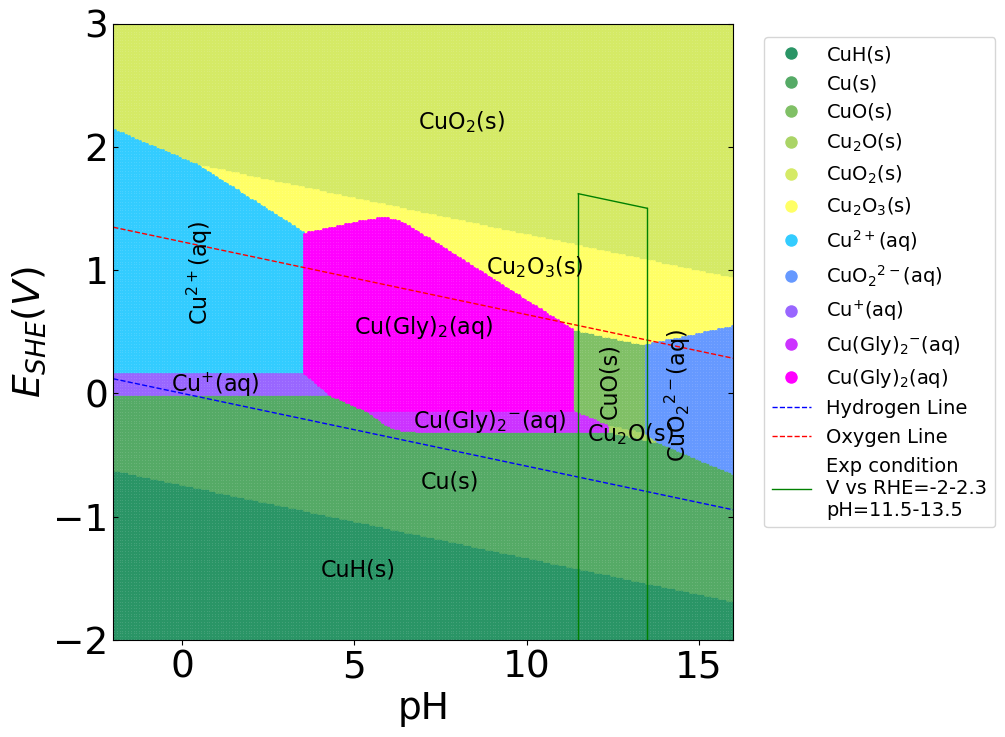

In [50]:
import matplotlib.pyplot as plt

def set_publication_style():
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelsize': 27,
        'axes.titlesize': 16,
        'xtick.labelsize': 27,
        'ytick.labelsize': 27,
        'legend.fontsize': 14,
        'figure.titlesize': 27,
        'savefig.dpi': 300,
    })

set_publication_style()





aqueous_only = {'NH3':0, 'NO2':0,
          'Gly': 0,
          'CN':0
                     }

no_CN = {'NH3':0.02,# 0.02M = 370 ppm, # M = molar
                      'NO2':0,
          'Gly': 0.005,#0.005,#0.005M = 370 ppm,
          'CN':0
                     }

with_CN={'NH3':0.02,# 0.02M = 370 ppm, # M = molar
          'NO2':0,
          'Gly': 0.005,#0.005M = 370 ppm,
          'CN':1e-4 
                     }

experiment_concentration = {'NH3':0.0,
          'NO2':0,
          'Gly': 0.1,
          'CN':0
}
ligand_concentration_list = [aqueous_only, no_CN, with_CN]
ligand_concentration_list = [no_CN, with_CN]
ligand_concentration_list = [experiment_concentration]

# Haldrian_experiment={'NH3':0.1,# 0.02M = 370 ppm, # M = molar
#                       'NO2':0,
#           'Gly': 0.1,#0.005M = 370 ppm,
#           'CN':0
#                      }
# ligand_concentration_list = [Haldrian_experiment]

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109,
           'CN':1.786800089,
           'NO2':-0.333729483
          }



metal_list = ['Au', 'Cu', 'Ni', 'Co',  'Mg', 'Mn','Ti', 'Zn', 'Ag', 'Sr','Pt','Pd','Fe'] #'Fe', ,'Ru','Bi','Ir'

metal_list = ['Cu']

metal_stable_regions = {}
activity = 1e-6
for metal in metal_list:
    for ligand_concentration in ligand_concentration_list:
        target_df = df[df['metal'] == metal]
        metal_complex = target_df.set_index('species')['del_G_eV'].to_dict()
        if metal == 'Pd':
            metal_complex['Pd(CN)4[2+]']=6.467825128
        if metal == 'Pt':
            metal_complex['Pt(CN)4[2+]']=5.646346039

    #     metal_complex['Ti(Gly)1[1+]']=-3.477626414
#         metal_complex['Pd(CN)4[2+]']=6.467825128
#         metal_complex['Pt(CN)4[2+]']=5.646346039 # harrington's stability constant = 70
        species_label_dict = target_df.set_index('species')['species_label'].to_dict()
#         print(species_label_dict)

        solid_file_path = f'data/{metal}_solid_formation_energy.json'
        ion_file_path = f'data/{metal}_ion_formation_energy.json'
        if os.path.exists(solid_file_path) and os.path.exists(ion_file_path):
            with open(solid_file_path, 'r') as file:
                solid_eng = json.load(file)
            with open(ion_file_path, 'r') as file:
                ion_eng = json.load(file)

        else:
            solid_eng = get_solid_formation_energy(metal)
            ion_eng = get_ion_formation_energy(metal)
        if 'FeOH[2+]' in ion_eng:
            ion_eng.pop('FeOH[2+]') 
        metal_data = Data(metal = metal,mu_bulk=solid_eng, #dft_form_eng, #exp_form_eng, 
        mu_aqueous_ion=ion_eng, 
        mu_complex = metal_complex, 
        mu_ligand=mu_ligand, ligand_concentration=ligand_concentration, ion_activity=activity)        
        thermo = Thermodynamics()

        combined_species = []
        for formula in metal_data.mu_bulk:
            species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='bulk', activity=0)
            combined_species.append(species)

        for formula in metal_data.mu_aqueous_ion:
            species = Species(formula=formula, metal=metal, thermo=thermo, data=metal_data, phase='aqueous_ion', activity=activity)
            combined_species.append(species)

        for formula in metal_data.mu_complex:
            species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='complex', activity=activity)
            combined_species.append(species)

        pH_range = (-2, 16)  # pH values
        V_range = (-2, 3)  # V values
        grid_size = 400  # Grid size
        plotter = GridPlotter(pH_range, V_range, metal_data, grid_size, save_fig = True)

        stability_calculator = StabilityCalculator(plotter, combined_species, thermo, metal_data)
        stable_regions = stability_calculator.compute_stable_regions()
        metal_stable_regions[metal] = stable_regions
    #     with open("data/{metal}_stable_regions.json", "w") as f:
    #         json.dump(stable_regions, f, indent=4)

        plotter.plot_stable_regions(stable_regions, species_label_dict)
    #     break

In [19]:
metal_complex

{'Cu(NH3)1[1+]': -0.1070779367,
 'Cu(NH3)2[1+]': -0.6729953533,
 'Cu(NH3)1[2+]': 0.15839697560000002,
 'Cu(NH3)2[2+]': -0.3235037022,
 'Cu(NH3)3[2+]': -0.7693126823,
 'Cu(NH3)4[2+]': -1.1701549571,
 'Cu(Gly)1[1+]': -3.1443832543,
 'Cu(Gly)2[1+]': -6.5996891948,
 'Cu(Gly)1[2+]': -3.0635085005000002,
 'Cu(Gly)2[2+]': -6.7400979645,
 'Cu(Gly)3[2+]': -9.1102863063,
 'Cu(CN)2[1+]': 2.6716051552,
 'Cu(CN)3[1+]': 4.1862383435,
 'Cu(CN)4[1+]': 5.8724550125,
 'Cu(NO2)1[2+]': 0.2740264759,
 'Cu(NO2)2[2+]': -0.0727196849,
 'Cu(NO2)3[2+]': -0.36029912820000004}

### Perturb DFT formation energies

In [60]:
import matplotlib.pyplot as plt
import random

def set_publication_style():
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelsize': 27,
        'axes.titlesize': 16,
        'xtick.labelsize': 27,
        'ytick.labelsize': 27,
        'legend.fontsize': 14,
        'figure.titlesize': 27,
        'savefig.dpi': 300,
    })

set_publication_style()





aqueous_only = {'NH3':0, 'NO2':0,
          'Gly': 0,
          'CN':0
                     }

no_CN = {'NH3':0.02,# 0.02M = 370 ppm, # M = molar
                      'NO2':0,
          'Gly': 0.005,#0.005,#0.005M = 370 ppm,
          'CN':0
                     }

with_CN={'NH3':0.02,# 0.02M = 370 ppm, # M = molar
                      'NO2':0,
          'Gly': 0.005,#0.005M = 370 ppm,
          'CN':1e-4 
                     }
ligand_concentration_list = [no_CN]

# Haldrian_experiment={'NH3':0.1,# 0.02M = 370 ppm, # M = molar
#                       'NO2':0,
#           'Gly': 0.1,#0.005M = 370 ppm,
#           'CN':0
#                      }
# ligand_concentration_list = [Haldrian_experiment]

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109,
           'CN':1.786800089,
           'NO2':-0.333729483
          }

# mu_ligand={'NH3':-0.276037,
#            'NO2':,
#           }

metal_list = ['Ni']

metal_stable_regions = {}
activity = 1e-4
noise_list = np.linspace(-0.2, 0.2, 4)

for noise in noise_list:
    for metal in metal_list:
        for ligand_concentration in ligand_concentration_list:
            target_df = df[df['metal'] == metal]
            metal_complex = target_df.set_index('species')['del_G_eV'].to_dict()
            if metal == 'Pd':
                metal_complex['Pd(CN)4[2+]']=6.467825128
            if metal == 'Pt':
                metal_complex['Pt(CN)4[2+]']=5.646346039

            species_label_dict = target_df.set_index('species')['species_label'].to_dict()

            solid_file_path = f'data/{metal}_solid_formation_energy.json'
            ion_file_path = f'data/{metal}_ion_formation_energy.json'
            if os.path.exists(solid_file_path) and os.path.exists(ion_file_path):
                with open(solid_file_path, 'r') as file:
                    solid_eng = json.load(file)
                with open(ion_file_path, 'r') as file:
                    ion_eng = json.load(file)

            else:
                solid_eng = get_solid_formation_energy(metal)
                ion_eng = get_ion_formation_energy(metal)
            if 'FeOH[2+]' in ion_eng:
                ion_eng.pop('FeOH[2+]') 
            metal_data = Data(metal = metal,mu_bulk=solid_eng, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=ion_eng, 
            mu_complex = metal_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration, ion_activity=activity)   

    #         choices = ['Ni2O2', 'Ni6O8', 'Ni2O4']
    #         chosen = random.choice(choices)

            # apply random Gaussian noise (mean 0, std dev 0.05)
            mu_bulk = metal_data.mu_bulk
#             noise = np.random.normal(loc=0.0, scale=0.2)
            mu_bulk['Ni2O2'] += noise

            print(f"Perturbed {chosen}: {mu_bulk[chosen]:.6f} (added noise: {noise:.6f})")

            thermo = Thermodynamics()

            combined_species = []
            for formula in metal_data.mu_bulk:
                species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='bulk', activity=0)
                combined_species.append(species)

            for formula in metal_data.mu_aqueous_ion:
                species = Species(formula=formula, metal=metal, thermo=thermo, data=metal_data, phase='aqueous_ion', activity=activity)
                combined_species.append(species)

            for formula in metal_data.mu_complex:
                species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='complex', activity=activity)
                combined_species.append(species)

            pH_range = (-2, 16)  # pH values
            V_range = (-2, 3)  # V values
            grid_size = 400  # Grid size
            plotter = GridPlotter(pH_range, V_range, metal_data, grid_size, save_fig = False)

            stability_calculator = StabilityCalculator(plotter, combined_species, thermo, metal_data)
            stable_regions = stability_calculator.compute_stable_regions()
            metal_stable_regions[metal] = stable_regions
            plotter.plot_stable_regions(stable_regions, species_label_dict)
            plt.savefig(f'Ni_gly_{noise}.png', bbox_inches='tight')



KeyError: 'species_label'

{'Ni2': 0.052284710000000345,
 'Ni': 0.0,
 'Ni2H': 0.4576537899999984,
 'NiH': 0.39332274000000034,
 'Ni3H': 2.554004720000002,
 'Ni2H6': 5.112658029999999,
 'Ni6H2': 4.908862370000001,
 'NiHO2': -2.9690197599999983,
 'NiH2O2': -1.1554175500000028,
 'Ni2H4O4': -2.323636690000008,
 'Ni4H8O8': -4.30819584000001,
 'NiO2': -1.4292143500000023,
 'Ni4O8': -5.553563249999996,
 'Ni6O8': -12.120652970000009,
 'Ni12O24': -14.412165329999993,
 'Ni5O6': -9.851344210000008,
 'Ni9O13': -13.717892465000006,
 'Ni15O16': -30.66235684000003,
 'Ni4O10': 0.5787181999999973,
 'NiO': 0.5081455249999998,
 'Ni4O3': -3.3413721750000036,
 'Ni2O4': -2.7043568899999997,
 'Ni5O11': -5.4323138250000085,
 'Ni5O4': -5.321263650000006,
 'NiO3': 2.711653094999999,
 'Ni8O16': -9.367761569999999,
 'Ni9O10': -17.89056899000002,
 'Ni4O': 4.830382005000004,
 'Ni2O2': -4.238879200000003,
 'Ni4O6': -3.9581542000000027,
 'Ni8O12': -11.462403060000014,
 'Ni12O14': -23.61233469000001,
 'Ni16O32': -5.5851714400000105,
 'Ni10O14':

In [39]:
metal_complex

{'Pt(NH3)4[2+]': -0.5517712226, 'Pt(CN)4[2+]': 5.646346039}

In [34]:
ion_eng

{'CuO(aq)': -1.0799227809423737,
 'CuOH[1+]': -1.4874990881403838,
 'Cu[2+]': 0.5009758043299483,
 'CuO2[2-]': -2.0818919989555367,
 'CuHO2[1-]': -2.858178468354925,
 'Cu[1+]': 0.3389506190679905}

In [15]:
unique_metal_stable_regions = set()
stable_dict = dict()
for metal in metal_stable_regions:
    for species, regions in metal_stable_regions[metal].items():
        formula = species.formula  # Convert Species to formula string
        if species.phase == 'bulk': #'bulk', 'aqueous_ion','ligand','complex'
            phase = '(s)'        
        if species.phase == 'aqueous_ion' or species.phase == 'complex':
            phase = '(aq)'   
        if formula in unique_metal_stable_regions:
            print(f"Duplicate species {formula} detected! Merging stability regions.")
        regions = np.array(regions)  # Convert list to NumPy array (if not already)
        has_true = np.any(regions)
        if has_true:
            unique_metal_stable_regions.add(formula)
            for i in range(len(regions)):
                for j in range(len(regions[0])):
                    if regions[i][j]:
                        if str((i,j)) in stable_dict:
                            stable_dict[str((i,j))].append(formula+f'{phase}')
                        else:
                            stable_dict[str((i,j))]=[formula+f'{phase}']
#     print(unique_metal_stable_regions)
with open(f"data/metal_stable_species.json", "w") as f:
    json.dump(list(unique_metal_stable_regions), f, indent=4)

# with open(f"data/Ti_Ni_stable_regions.json", "w") as f:
#     json.dump(stable_dict, f, indent=4)



In [12]:
unique_metal_stable_regions

set()

In [ ]:
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt

def find_boundaries(stable_regions, grid):
    boundary_coords = {}

    for species, stable_mask in stable_regions.items():
        # Use binary dilation to expand the region and find edges
        dilated_mask = scipy.ndimage.binary_dilation(stable_mask)
        boundary_mask = dilated_mask & ~stable_mask  # Boundaries: expanded region minus original
        
        # Get x, y indices of boundary points
        y_indices, x_indices = np.where(boundary_mask)

        # Convert indices to real pH and E values
        pH_values = grid.pH_range[0] + (x_indices / grid.grid_size) * (grid.pH_range[1] - grid.pH_range[0])
        E_values = grid.V_range[0] + (y_indices / grid.grid_size) * (grid.V_range[1] - grid.V_range[0])

        # Store as list of (pH, E) pairs
        boundary_coords[species] = list(zip(pH_values, E_values))

    return boundary_coords
# boundaries_Ti = find_boundaries(metal_stable_regions['Ti'], plotter)
# boundaries_Ni = find_boundaries(metal_stable_regions['Ni'], plotter)


### Fe

In [ ]:
import pandas as pd
import json
import os
# ligand_concentration={'NH3':0.5, # M = molar
#           'Gly': 0.5}

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109        
          }

metal_list = ['Au', 'Cu', 'Ni', 'Co', 'Fe', 'Mg', 'Mn', 'Na', 'Ca', 'Ti', 'Cd']
metal_list = ['Fe']
for metal in metal_list:
    df = pd.read_json('data/metal_complex_del_G.json')
    target_df = df[df['metal'] == metal]
    metal_complex = target_df.set_index('species')['del_G_eV'].to_dict()
    
    solid_file_path = f'data/{metal}_solid_formation_energy.json'
    ion_file_path = f'data/{metal}_ion_formation_energy.json'
    
    if os.path.exists(solid_file_path) and os.path.exists(ion_file_path):
        with open(solid_file_path, 'r') as file:
            solid_eng = json.load(file)
        with open(ion_file_path, 'r') as file:
            ion_eng = json.load(file)
       
    else:
        solid_eng = get_solid_formation_energy(metal)
        ion_eng = get_ion_formation_energy(metal)
    ion_eng.pop('FeOH[2+]')
    metal_data = Data(metal = metal,mu_bulk=solid_eng, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=ion_eng, 
            mu_complex = metal_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration,ion_activity=activity)          
    thermo = Thermodynamics()

    combined_species = []

    activity = 1e-4
    for formula in metal_data.mu_bulk:
        species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='bulk', activity=0)
        combined_species.append(species)

    for formula in metal_data.mu_aqueous_ion:
        species = Species(formula=formula, metal=metal, thermo=thermo, data=metal_data, phase='aqueous_ion', activity=activity)
        combined_species.append(species)

    for formula in metal_data.mu_complex:
        species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='complex', activity=activity)
        combined_species.append(species)

    pH_range = (-2, 16)  # pH values
    V_range = (-2, 3)  # V values
    grid_size = 400  # Grid size
    plotter = GridPlotter(pH_range, V_range, metal_data, grid_size, save_fig = True)

    stability_calculator = StabilityCalculator(plotter, combined_species, thermo, metal_data)
    stable_regions = stability_calculator.compute_stable_regions()
    plotter.plot_stable_regions(stable_regions)

### Sr

In [ ]:
import pandas as pd
import json
import os
ligand_concentration={'NH3':0.0, # M = molar
          'Gly': 0.13}

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109        
          }

metal_list = ['Au', 'Cu', 'Ni', 'Co', 'Fe', 'Mg', 'Mn', 'Na', 'Ca', 'Ti', 'Cd']
metal_list = ['Sr']
for metal in metal_list:
    df = pd.read_json('data/metal_complex_del_G.json')
    target_df = df[df['metal'] == metal]
    metal_complex = target_df.set_index('species')['del_G_eV'].to_dict()
    
    solid_file_path = f'data/{metal}_solid_formation_energy.json'
    ion_file_path = f'data/{metal}_ion_formation_energy.json'
    
    if os.path.exists(solid_file_path) and os.path.exists(ion_file_path):
        with open(solid_file_path, 'r') as file:
            solid_eng = json.load(file)
        with open(ion_file_path, 'r') as file:
            ion_eng = json.load(file)
       
    else:
        solid_eng = get_solid_formation_energy(metal)
        ion_eng = get_ion_formation_energy(metal)
#     ion_eng.pop('FeOH[2+]')
    metal_data = Data(metal = metal,mu_bulk=solid_eng, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=ion_eng, 
            mu_complex = metal_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration,ion_activity=activity)          
    thermo = Thermodynamics()

    combined_species = []

    activity = 1e-4
#     solid_eng.pop('Sr2O20')
#     solid_eng.pop('SrO10')
    for formula in metal_data.mu_bulk:
        species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='bulk', activity=0)
        combined_species.append(species)

    for formula in metal_data.mu_aqueous_ion:
        species = Species(formula=formula, metal=metal, thermo=thermo, data=metal_data, phase='aqueous_ion', activity=activity)
        combined_species.append(species)

    for formula in metal_data.mu_complex:
        species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='complex', activity=activity)
        combined_species.append(species)

    pH_range = (-2, 16)  # pH values
    V_range = (-2, 3)  # V values
    grid_size = 400  # Grid size
    plotter = GridPlotter(pH_range, V_range, metal_data, grid_size, save_fig = False)

    stability_calculator = StabilityCalculator(plotter, combined_species, thermo, metal_data)
    stable_regions = stability_calculator.compute_stable_regions()
    plotter.plot_stable_regions(stable_regions)

In [ ]:
target_df

### Ti

In [ ]:
import pandas as pd
import json
import os
ligand_concentration={'NH3':0., # M = molar
          'Gly': 5}

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109        
          }

metal_list = ['Au', 'Cu', 'Ni', 'Co', 'Fe', 'Mg', 'Mn', 'Na', 'Ca', 'Ti']
metal_list = ['Ti']
for metal in metal_list:
    df = pd.read_json('data/metal_complex_del_G.json')
    target_df = df[df['metal'] == metal]
    metal_complex = target_df.set_index('species')['del_G_eV'].to_dict()
    
    solid_file_path = f'data/{metal}_solid_formation_energy.json'
    ion_file_path = f'data/{metal}_ion_formation_energy.json'
    
    if os.path.exists(solid_file_path) and os.path.exists(ion_file_path):
        with open(solid_file_path, 'r') as file:
            solid_eng = json.load(file)
        with open(ion_file_path, 'r') as file:
            ion_eng = json.load(file)
       
    else:
        solid_eng = get_solid_formation_energy(metal)
        ion_eng = get_ion_formation_energy(metal)
#     ion_eng['FeOH[1+]'] = ion_eng['FeOH[2+]']
#     ion_eng.pop('FeOH[2+]')
    metal_data = Data(metal = metal,mu_bulk=solid_eng, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=ion_eng, 
            mu_complex = metal_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration)        
    thermo = Thermodynamics()

    combined_species = []

    activity = 1e-6
    for formula in metal_data.mu_bulk:
        species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='bulk', activity=0)
        combined_species.append(species)

    for formula in metal_data.mu_aqueous_ion:
        species = Species(formula=formula, metal=metal, thermo=thermo, data=metal_data, phase='aqueous_ion', activity=activity)
        combined_species.append(species)

    for formula in metal_data.mu_complex:
        species = Species(formula=formula, metal=metal,thermo=thermo, data=metal_data, phase='complex', activity=activity)
        combined_species.append(species)

    pH_range = (-2, 16)  # pH values
    V_range = (-2, 3)  # V values
    grid_size = 400  # Grid size
    plotter = GridPlotter(pH_range, V_range, metal_data, grid_size, save_fig = False)

    stability_calculator = StabilityCalculator(plotter, combined_species, thermo, metal_data)
    stable_regions = stability_calculator.compute_stable_regions()
    plotter.plot_stable_regions(stable_regions)

In [ ]:
metal_complex

### Cu Pbx diagram

In [ ]:
########################## Load data #############################
import pandas as pd
import json 
metal = 'Cu'
df = pd.read_json('data/metal_complex_del_G.json')

cu_df = df[df['metal'] == metal]

Cu_complex = cu_df.set_index('species')['del_G_eV'].to_dict()
 
with open(f'data/{metal}_solid_formation_energy.json', 'r') as file:
    Cu_solid = json.load(file)
with open(f'data/{metal}_ion_formation_energy.json', 'r') as file:
    Cu_ion = json.load(file)
    
#######################################################    
    
ligand_concentration={'NH3':0.5, # M = molar
          'Gly': 0.16}

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109        
          }

Cu_data = Data(metal = metal,mu_bulk=Cu_solid, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=Cu_ion, 
            mu_complex = Cu_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration)        
thermo = Thermodynamics()

combined_species = []

activity = 0.02#1e-2
for formula in Cu_data.mu_bulk:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Cu_data, phase='bulk', activity=0)
    combined_species.append(species)
    
for formula in Cu_data.mu_aqueous_ion:
    species = Species(formula=formula, metal=metal, thermo=thermo, data=Cu_data, phase='aqueous_ion', activity=activity)
    combined_species.append(species)
    
for formula in Cu_data.mu_complex:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Cu_data, phase='complex', activity=activity)
    combined_species.append(species)

pH_range = (-2, 16)  # pH values
V_range = (-2, 3)  # V values
grid_size = 400  # Grid size
plotter = GridPlotter(pH_range, V_range, Cu_data, grid_size, save_fig = False)

stability_calculator = StabilityCalculator(plotter, combined_species, thermo, Cu_data)
stable_regions = stability_calculator.compute_stable_regions()
plotter.plot_stable_regions(stable_regions)


### Ni

In [ ]:
########################## Load data #############################
import pandas as pd
import json 
metal = 'Ni'
df = pd.read_json('data/metal_complex_del_G.json')

Ni_df = df[df['metal'] == metal]

Ni_complex = Ni_df.set_index('species')['del_G_eV'].to_dict()
 
with open(f'data/{metal}_solid_formation_energy.json', 'r') as file:
    Ni_solid = json.load(file)
with open(f'data/{metal}_ion_formation_energy.json', 'r') as file:
    Ni_ion = json.load(file)
    
#######################################################    
    
ligand_concentration={'NH3':1, # M = molar
          'Gly': 0.16}

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109        
          }

Ni_data = Data(metal = metal,mu_bulk=Ni_solid, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=Ni_ion, 
            mu_complex = Ni_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration)        
thermo = Thermodynamics()

combined_species = []

activity = 0.02#1e-2
for formula in Ni_data.mu_bulk:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Ni_data, phase='bulk', activity=0)
    combined_species.append(species)
    
for formula in Ni_data.mu_aqueous_ion:
    species = Species(formula=formula, metal=metal, thermo=thermo, data=Ni_data, phase='aqueous_ion', activity=activity)
    combined_species.append(species)
    
for formula in Ni_data.mu_complex:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Ni_data, phase='complex', activity=activity)
    combined_species.append(species)

    pH_range = (-2, 16)  # pH values
V_range = (-2, 3)  # V values
grid_size = 400  # Grid size
plotter = GridPlotter(pH_range, V_range, Ni_data, grid_size, save_fig = False)

stability_calculator = StabilityCalculator(plotter, combined_species, thermo, Ni_data)
stable_regions = stability_calculator.compute_stable_regions()
plotter.plot_stable_regions(stable_regions)


### Gold Pbx diagram


In [ ]:
lo_pH, hi_pH = -2, 16
lo_eU, hi_eU = -2, 3
bbox = [(lo_pH, hi_pH), (lo_eU, hi_eU)]
mu_H2O = -2.458#- kB*T*np.log(10)*6
T =  298.15 #K
kB = 8.6173e-5 #eV/K 

Au_ion = {
    'AuO3[3-]': -1.6102220680824748,
 'HAuO3[2-]': -1.1968492770737058,#-2.5469272554172937,
 'H2AuO3[1-]': -3.336065463428902,
 'Au[3+]': 3.381973610002202,
 'H3AuO3(aq)': -4.010470811410453
         }
Au_solid = {'Au': 0.0,
 'Au2': 0.010602200000000117,
            'AuO2':2.081477003606445,
 'HAuO2': -1.6659787400000035,
 'H2Au2O4': -3.4903926700000056,
 'Au4O6': -2.678147950000003,
 'Au6O2': 2.205748909999997
           
           }

Au_complex = {
    
    'Au(Gly)2[1+]':-5.895480063985564, #-7.7901129,
'Au(Gly)1[3+]':0.880139182,
'Au(Gly)2[3+]':-2.591141772,
    
# 'Au(Gly)2[1-]':-5.895480063985564, #-7.7901129,
# 'Au(Gly)1[2+]':0.880139182,
# 'Au(Gly)2[1+]':-2.591141772,
'Au(NH3)2[1+]':-0.398646210294876,#-0.325390915,
'Au(NH3)4[3+]':0.66785#1.68127512
}
ligand_concentration={'NH3':1, # M = molar
          'Gly': 1}

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109}

In [ ]:

metal = 'Au'

Au_data = Data(metal = metal,mu_bulk=Au_solid, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=Au_ion, 
            mu_complex = Au_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration)        
thermo = Thermodynamics()

combined_species = []

mu_bulk=dft_form_eng
# mu_bulk=exp_form_eng

mu_aqueous_ion=mu_ion
mu_complex = mu_ligand_complex
activity = 1e-4
for formula in Au_data.mu_bulk:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Au_data, phase='bulk', activity=0)
    combined_species.append(species)
    
for formula in Au_data.mu_aqueous_ion:
    species = Species(formula=formula, metal=metal, thermo=thermo, data=Au_data, phase='aqueous_ion', activity=activity)
    combined_species.append(species)
    
for formula in Au_data.mu_complex:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Au_data, phase='complex', activity=activity)
    combined_species.append(species)

pH_range = (-2, 16)  # pH values
V_range = (-2, 3)  # V values
grid_size = 400  # Grid size
plotter = GridPlotter(pH_range, V_range, Au_data, grid_size, save_fig = True)

stability_calculator = StabilityCalculator(plotter, combined_species, thermo, Au_data)
stable_regions = stability_calculator.compute_stable_regions()
plotter.plot_stable_regions(stable_regions)


In [ ]:
########################## Load data #############################
import pandas as pd
import json 
metal = 'Au'
df = pd.read_json('data/metal_complex_del_G.json')

Ni_df = df[df['metal'] == metal]

Ni_complex = Ni_df.set_index('species')['del_G_eV'].to_dict()
# Ni_complex['Au(Gly)2[1+]']=-5.895480063985564 #double check this value
with open(f'data/{metal}_solid_formation_energy.json', 'r') as file:
    Ni_solid = json.load(file)
with open(f'data/{metal}_ion_formation_energy.json', 'r') as file:
    Ni_ion = json.load(file)
    
#######################################################    
    
ligand_concentration={'NH3':0., # M = molar
          'Gly': 0.16}

mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109        
          }

Ni_data = Data(metal = metal,mu_bulk=Ni_solid, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=Ni_ion, 
            mu_complex = Ni_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration)        
thermo = Thermodynamics()

combined_species = []

activity = 1e-4
for formula in Ni_data.mu_bulk:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Ni_data, phase='bulk', activity=0)
    combined_species.append(species)
    
for formula in Ni_data.mu_aqueous_ion:
    species = Species(formula=formula, metal=metal, thermo=thermo, data=Ni_data, phase='aqueous_ion', activity=activity)
    combined_species.append(species)
    
for formula in Ni_data.mu_complex:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Ni_data, phase='complex', activity=activity)
    combined_species.append(species)

    pH_range = (-2, 16)  # pH values
V_range = (-2, 3)  # V values
grid_size = 400  # Grid size
plotter = GridPlotter(pH_range, V_range, Ni_data, grid_size, save_fig = False)

stability_calculator = StabilityCalculator(plotter, combined_species, thermo, Ni_data)
stable_regions = stability_calculator.compute_stable_regions()
plotter.plot_stable_regions(stable_regions)


In [ ]:
Ni_complex

In [ ]:
lo_pH, hi_pH = -2, 16
lo_eU, hi_eU = -2, 3
bbox = [(lo_pH, hi_pH), (lo_eU, hi_eU)]
mu_H2O = -2.458#- kB*T*np.log(10)*6
T =  298.15 #K
kB = 8.6173e-5 #eV/K 

mu_ligand_complex={
    'Ni(NH3)1[2+]':-0.910147,
    'Ni(NH3)2[2+]':-1.314653,
    'Ni(NH3)3[2+]':-1.689215,
    'Ni(NH3)4[2+]':-2.031668,
    'Ni(NH3)5[2+]':-2.347246,
    'Ni(NH3)6[2+]':-2.621501,
    
    'Ni(Gly)1[2+]':-4.08116651, #-4.087083182,
    'Ni(Gly)2[2+]':-7.628180863 ,#-7.640014207,
    'Ni(Gly)3[2+]':-11.06514512
    
#     'Ni(Gly)1[1+]':-4.08116651, #-4.087083182,
#     'Ni(Gly)2':-7.628180863 ,#-7.640014207,
#     'Ni(Gly)3[1-]':-11.06514512
#     -11.09532015
}
dft_form_eng = {
    'Ni':0,
    'NiOOH':-0.85 * 4,
    'NiO':-1.35 * 2,
    'Ni3O4': -0.99 * 7,
    'Ni2O3':-0.8 * 5,
    'NiO2': -0.45 * 3,
}
exp_form_eng = {
     'Ni':0,
    'NiO':-2.188, #-1.1 * 2,
    'Ni3O4': -7.33, #-1.05 * 7,
    'Ni2O3': -4.869, #-1 * 5,
    'NiO2': -2.230, #-0.7 * 3,
    'Ni(OH)2':-4.696, #-0.95 * 5,
#     'NiOOH':-3.406, #-0.85 * 4,
}

mu_ion = {
    'Ni[3+]': +3.745,
    'NiOH[1+]' : -2.355,
    'Ni[2+]': -0.456,# - kB*T*np.log(10)*6, #-0.456, #-0.5, #
    'Ni(OH)3[1-]': -6.077,#- kB*T*np.log(10)*6,
    'Ni(OH)4[2-]':-7.708,#- kB*T*np.log(10)*6,
}
mu_ligand={'NH3':-0.276037,
          'Gly': -3.263014109}





In [ ]:
ligand_concentration={'NH3':0.15, # M = molar
          'Gly': 0.15}
metal = 'Ni'

Ni_data = Data(metal = metal,
            mu_bulk=exp_form_eng, #dft_form_eng, #exp_form_eng, 
            mu_aqueous_ion=mu_ion, 
            mu_complex = mu_ligand_complex, 
            mu_ligand=mu_ligand, ligand_concentration=ligand_concentration)        
thermo = Thermodynamics()

combined_species = []

mu_bulk=dft_form_eng
# mu_bulk=exp_form_eng

mu_aqueous_ion=mu_ion
mu_complex = mu_ligand_complex
activity = 1e-4
for formula in Ni_data.mu_bulk:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Ni_data, phase='bulk', activity=0)
    combined_species.append(species)
    
for formula in Ni_data.mu_aqueous_ion:
    species = Species(formula=formula, metal=metal, thermo=thermo, data=Ni_data, phase='aqueous_ion', activity=activity)
    combined_species.append(species)
    
for formula in Ni_data.mu_complex:
    species = Species(formula=formula, metal=metal,thermo=thermo, data=Ni_data, phase='complex', activity=activity)
    combined_species.append(species)

pH_range = (-2, 16)  # pH values
V_range = (-2, 3)  # V values
grid_size = 400  # Grid size
plotter = GridPlotter(pH_range, V_range, Ni_data, grid_size, save_fig = True)

stability_calculator = StabilityCalculator(plotter, combined_species, thermo, Ni_data)
stable_regions = stability_calculator.compute_stable_regions()
plotter.plot_stable_regions(stable_regions)
